## Determine the shell intervals

In [1]:
from shell.data import MolDataset


dataset = MolDataset(
    'qm9',
    feature_names=['x', 'pos', 'z'],
    processed_path='dataset/qm9/qm9.pt',
    force_reload=False,
    remove_hydrogens=False,
    add_smiles=True,
    n_samples=-1,
)

TypeError: MolDataset.__init__() got an unexpected keyword argument 'processed_path'

In [ ]:
import torch

distance = [torch.norm(data['pos'], dim=1) for data in dataset]
distance = torch.cat(distance, dim=0)
distance

tensor([2.8285e-05, 1.0919e+00, 1.0919e+00,  ..., 2.8163e+00, 2.1658e+00,
        2.5855e+00])

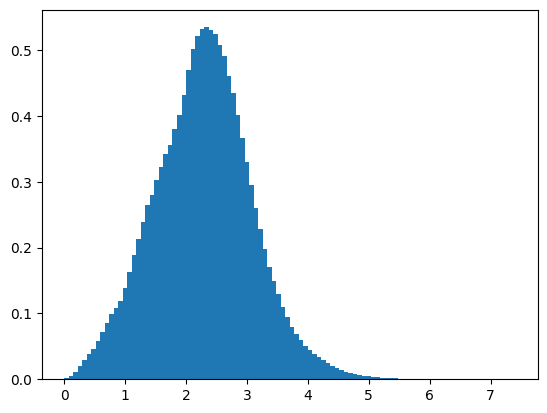

In [ ]:
from matplotlib import pyplot as plt

plt.hist(distance, bins=100, density=True)
plt.show()

In [ ]:
torch.max(distance), torch.min(distance)

(tensor(7.4043), tensor(9.5375e-06))

In [ ]:
import numpy as np

def identify_intervals(
    n: int,
    distance: torch.Tensor,
    max_val: float = None, 
    min_val: float = 0.0, 
    num_bins: int = 100
):
    if max_val is None:
        max_val = torch.max(distance)
    
    hist = torch.histogram(
        distance, bins=num_bins, range=(min_val, max_val), density=True
    )
    bin_widths = hist.bin_edges[1:] - hist.bin_edges[:-1]
    bin_areas = hist.hist * bin_widths
    cumu_areas = torch.cumsum(bin_areas, dim=0)
    total_area = cumu_areas[-1]
    target_areas = torch.linspace(0, total_area, steps=n + 1)[1:-1]
    intervals = np.interp(target_areas, cumu_areas, hist.bin_edges[1:])
    return torch.tensor(intervals)

In [ ]:
intervals = identify_intervals(10, distance, max_val=8.0)

In [ ]:
torch.round(intervals, decimals=2)

tensor([1.2400, 1.6100, 1.8800, 2.1100, 2.3000, 2.4900, 2.6900, 2.9200, 3.2700],
       dtype=torch.float64)

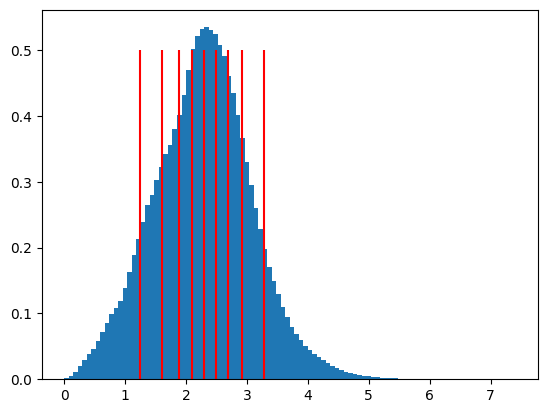

In [ ]:
plt.hist(distance.numpy(), bins=100, density=True)
plt.vlines(intervals, 0, 0.5, colors='r')
plt.show()

In [ ]:
torch.bucketize(distance[1000:1005], intervals, right=True)

tensor([3, 3, 2, 5, 6])

In [ ]:
intervals, distance[:5]

(tensor([1.2426, 1.6055, 1.8820, 2.1051, 2.2968, 2.4851, 2.6855, 2.9231, 3.2742],
        dtype=torch.float64),
 tensor([2.8285e-05, 1.0919e+00, 1.0919e+00, 1.0919e+00, 1.0919e+00]))

## Rebuild the dataset

In [5]:
from shell.data import MolDataset, AVAIL_FEATURES


dataset = MolDataset(
    'qm9',
    feature_names=['x', 'pos', 'z', 'radius'],
    processed_name='sample.pt',
    force_reload=False,
    remove_hydrogens=False,
    add_smiles=True,
    n_samples=1000,
)

In [6]:
from shell.data import Mol, SphMol
from torch_geometric.loader import DataLoader
import torch


mol: Mol = next(iter(DataLoader(dataset[600:], batch_size=1)))
sphmol1 = SphMol.from_mol(mol)
sphmol0 = sphmol1.get_prior()

In [7]:
from shell.path import SphMolPath

path = SphMolPath()
pos_traj = []
z_traj = []
for t in torch.linspace(0, 1, steps=100):
    t = torch.tensor([t])[mol.batch]
    sphmolt, dvdt, drdt = path.sample(sphmol0, sphmol1, t)
    mol = sphmolt.to_mol()
    pos_traj.append(mol.pos)
    z_traj.append(mol._get_atom_num(unique_atom_nums=torch.tensor(dataset.unique_atom_nums)))
t = torch.tensor([0.5])[mol.batch]
sphmolt, dvdt, drdt = path.sample(sphmol0, sphmol1, t)

In [11]:
pos_traj[3].mean(0)

tensor([ 0.4442, -0.3517, -0.6815])

In [4]:
from shell.utils.visualizer import visualize_mol, visualize_traj

# visualize_traj(z_traj, pos_traj, interval=200)

In [5]:
sphmol0.get_cartesian().norm(dim=1)

tensor([1.8329, 2.4155, 2.5263, 1.7863, 1.9089, 2.1777, 2.3846, 2.3294, 3.1679,
        1.4661, 1.7951, 2.1596, 3.1592])

In [6]:
from shell.model import EGNNVectorField, GVPVectorField

vf = EGNNVectorField(
    in_node_nf=6,
    context_node_nf=0
)
# vf = GVPVectorField(
#     in_node_nf=6
# )
xt, vt, rt = vf(sphmolt.to_mol(), t.unsqueeze(1))

In [7]:
from flow_matching.loss import MixturePathGeneralizedKL
from shell.data.mol import RadiusTransform
from torch import nn

loss_fn = {
    'x': nn.CrossEntropyLoss(),
    'v': nn.MSELoss(),
    'r': nn.MSELoss()
}

In [8]:
loss_fn['x'](xt, sphmol1.x.argmax(dim=1)), \
    loss_fn['v'](vt, dvdt), \
    loss_fn['r'](rt, drdt)

(tensor(1.6680, grad_fn=<NllLossBackward0>),
 tensor(1.0922, grad_fn=<MseLossBackward0>),
 tensor(3.5606, grad_fn=<MseLossBackward0>))

In [13]:
from shell.path.solver import SphMolSolver


solver = SphMolSolver(vf, x_path=path.x_path, unique_atom_nums=dataset.unique_atom_nums, n_steps=250)

In [14]:
samples = solver.sample(sphmol0)

Sampling: 100%|██████████| 249/249 [00:01<00:00, 164.28it/s]


In [15]:
samples[0].view()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [16]:
num_nodes = torch.tensor([16, 7, 9])
torch.repeat_interleave(torch.arange(len(num_nodes)), num_nodes)

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 2,
        2, 2, 2, 2, 2, 2, 2, 2])

In [1]:
from shell import ShellFlow
import torch

flow = ShellFlow.load_from_checkpoint(
    checkpoint_path='.shell_output/flow(2025-03-18_12-09-39)/ckpt/last.ckpt',
    config='.shell_output/flow(2025-03-18_12-09-39)/config.yaml'
)
samples = flow.sample(torch.tensor([8]), record_traj=True)

Sampling: 100%|██████████| 249/249 [00:03<00:00, 72.05it/s]


In [ ]:
samples[0].view_trajs()